# Postie Data Challenge — Analysis and Responses

This notebook builds on the initial exploratory analysis and focuses on answering the primary questions in the Postie data challenge.

## How to Read This Notebook

Each question begins with a short answer summary. The code and visualizations underneath provide supporting evidence. For a quick review, read the highlighted answer boxes and conclusions; the intermediate code cells are included for reproducibility.

## Challenge Questions Addressed

This notebook is organized around the questions provided in the challenge prompt:

1. Why was the reported `2017-07-03` sales value lower than the previous day’s sales summary?
2. What other key metrics should be reported for the system? Is average daily sales the right metric?
3. What information can be extracted from the URLs? Can all product prices be inferred?
4. Are there interesting purchasing combinations, events, or metrics worth reporting?
5. Can total sales for `2017-07-04` be predicted? How certain is the prediction?
6. What additional information, data, or access would improve the prediction?

In [47]:
# ------------------------------------------------------------
# Imports, paths, and cleaned data load
# ------------------------------------------------------------

from pathlib import Path
import pandas as pd
import numpy as np
import datetime

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR = OUTPUTS_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Plot styling
# ------------------------------------------------------------

sns.set_theme(style="white", context="talk")

TITLE_STYLE = {
    "fontsize": 20,
    "fontweight": "bold",
    "pad": 18
}

AXIS_LABEL_STYLE = {
    "fontsize": 15,
    "fontweight": "bold",
    "labelpad": 10
}

TARGET_DATE = pd.to_datetime("2017-07-03").date()
PREDICTION_DATE = pd.to_datetime("2017-07-04").date()

TARGET_COLOR = "#F28E2B"  # orange highlight
GREY_COLORS = ["#cfcfcf", "#9f9f9f", "#6f6f6f", "#d9d9d9", "#b5b5b5"]

In [48]:
# ------------------------------------------------------------
# Make long strings easier to read in notebook output
# ------------------------------------------------------------
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 200)

In [49]:
# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def plot_daily_bar(
    data,
    y_col,
    title,
    y_label,
    filename=None,
    money_axis=False,
    value_format="{:,.0f}",
    figsize=(10, 6),
    save_fig=False
):
    plot_data = data.copy().sort_values("date")
    
    colors = [
        TARGET_COLOR if date == TARGET_DATE else GREY_COLORS[i % len(GREY_COLORS)]
        for i, date in enumerate(plot_data["date"])
    ]
    
    plt.figure(figsize=figsize)

    ax = sns.barplot(
        data=plot_data,
        x="date",
        y=y_col,
        hue="date",
        palette=colors,
        legend=False
    )

    for patch in ax.patches:
        height = patch.get_height()
        label = f"${height:,.0f}" if money_axis else value_format.format(height)

        ax.text(
            patch.get_x() + patch.get_width() / 2,
            height,
            label,
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold"
        )

    plt.title(title, **TITLE_STYLE)
    plt.xlabel("Date", **AXIS_LABEL_STYLE)
    plt.ylabel(y_label, **AXIS_LABEL_STYLE)

    if money_axis:
        ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
    else:
        ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

    plt.xticks(rotation=45, fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(False)
    sns.despine()
    plt.tight_layout()

    if save_fig:
        if filename is None:
            raise ValueError("filename must be provided when save_fig=True")
        plt.savefig(FIGURES_DIR / filename, dpi=300, bbox_inches="tight")

    plt.show()

print('Loaded helpers')

Loaded helpers


In [50]:
# ------------------------------------------------------------
# Load cleaned transaction data
# ------------------------------------------------------------

cleaned_data_path = DATA_PROCESSED / "transactions_clean.csv"

df = pd.read_csv(cleaned_data_path)

# Restore analysis-friendly dtypes
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)
df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.date
df["hour"] = pd.to_numeric(df["hour"], errors="coerce").astype("Int64")

df["website_id"] = pd.to_numeric(df["website_id"], errors="coerce").astype("Int64")
df["customer_id"] = pd.to_numeric(df["customer_id"], errors="coerce").astype("Int64")
df["checkout_amount"] = pd.to_numeric(df["checkout_amount"], errors="coerce")

df["app_version"] = df["app_version"].astype("string")
df["url"] = df["url"].astype("string")
df["source_file"] = df["source_file"].astype("string")

# Confirmation
print(f"Loaded cleaned data: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Total sales: ${df['checkout_amount'].sum():,.2f}")
print(f"Missing timestamps: {df['timestamp'].isna().sum()}")
print(f"Missing checkout amounts: {df['checkout_amount'].isna().sum()}")

Loaded cleaned data: 33,188 rows x 11 columns
Date range: 2017-07-01 00:00:15+00:00 to 2017-07-03 23:59:57+00:00
Total sales: $588,850.00
Missing timestamps: 0
Missing checkout amounts: 0


<div style="background-color:#fff3cd; padding:16px; border-left:6px solid #f0ad4e; border-radius:6px;">

## Question 1: Why was the reported July 3 sales value lower than the previous day?
</div>

<div style="background-color:#f7f7f7; padding:18px; border-left:6px solid #f28e2b; border-radius:6px;">

### Answer Summary

The reported July 3 sales value appears low because it was calculated using the raw `2017-07-03.csv` source file rather than UTC-normalized transaction dates.

The reported value of `$164,065.00` is reproducible: it matches the total sales value in the raw July 3 source file exactly. However, after normalizing timestamps to UTC and grouping transactions by transaction date, I calculate July 3 sales as `$181,583.00`.

Under the UTC-normalized calculation, July 3 is only `$2,169.00` lower than July 2, a decrease of about `1.2%`, while transaction count actually increases. This suggests the original report overstated the size of the drop because the daily grouping method was inconsistent with the timestamp normalization used in this analysis.

</div>

### Date Handling

The previously reported July 3 sales value is reproducible, but it depends on how "July 3" is defined.

When I group transactions by the raw source file, the `2017-07-03.csv` file totals **$164,065.00**, which matches the reported value exactly. However, after normalizing timestamps to UTC and grouping transactions by the normalized transaction date, July 3 totals **$181,583.00**.

This means the reported value does not appear to be arbitrary or fabricated; it appears to be based on the July 3 source file. The discrepancy comes from date assignment. Because the timestamps include timezone information, grouping by file name and grouping by normalized transaction date do not produce the same daily totals.

For the rest of this analysis, I use UTC-normalized transaction dates so daily comparisons share a consistent date boundary.


| Definition | July 3 Sales | Difference from Reported |
|:--|--:|--:|
| Reported July 3 value | `$164,065` | `$0` |
| Raw source-file grouping | `$164,065` | `$0` |
| UTC-normalized transaction date | `$181,583` | `$17,518` |


### Note on Negative Checkout Amounts

July 3 also contains `17` negative checkout values. Each is exactly `-12`, for a total negative contribution of `-$204`.

These transactions are notable because they occur only on July 3 and appear across both website IDs and both app versions. They do not explain the full difference between `$164,065.00` and `$181,583.00`, but they are unusual enough to flag before finalizing revenue reporting.

If the `-12` values are valid negative revenue events, they should remain included. If they are errors and should be excluded, July 3 sales would increase to `$181,787`. If they are sign errors and should have been positive `$12` transactions, July 3 sales would increase to `$181,991`.

### Conclusion

The reported July 3 value appears lower than expected mainly because of date-boundary handling. The `$164,065.00` figure is not arbitrary; it matches the raw July 3 source file total. However, once timestamps are normalized to UTC and transactions are grouped by normalized transaction date, July 3 sales increase to `$181,583.00`.

July 3 is still slightly lower than July 2 in total sales, but the gap is modest and occurs despite higher transaction volume. The negative `-$12` checkout values are also worth flagging, but they are too small to explain the difference between the reported and normalized totals.

Overall, the evidence points more toward timestamp/date-boundary handling than a major decline in sales activity.

In [51]:
# ------------------------------------------------------------
# Investigate reported July 3 sales 
# ------------------------------------------------------------

# Analyst-reported value from the challenge prompt
reported_july_03_sales = 164_065.00
target_date = pd.to_datetime("2017-07-03").date()

# Make sure date fields exist
if "date" not in df.columns:
    df["date"] = df["timestamp"].dt.date

if "hour" not in df.columns:
    df["hour"] = df["timestamp"].dt.hour

if "day_of_week" not in df.columns:
    df["day_of_week"] = df["timestamp"].dt.day_name()

# ------------------------------------------------------------
# Daily summary
# ------------------------------------------------------------

daily_summary = (
    df.groupby("date")
    .agg(
        transactions=("checkout_amount", "size"),
        total_sales=("checkout_amount", "sum"),
        average_order_value=("checkout_amount", "mean"),
        median_order_value=("checkout_amount", "median"),
        min_order_value=("checkout_amount", "min"),
        max_order_value=("checkout_amount", "max"),
        unique_customers=("customer_id", "nunique"),
        unique_websites=("website_id", "nunique"),
        app_versions=("app_version", "nunique"),
        source_files=("source_file", "nunique"),
    )
    .reset_index()
    .sort_values("date")
)

# Add comparison columns
daily_summary["sales_change_vs_prior_day"] = daily_summary["total_sales"].diff()
daily_summary["sales_pct_change_vs_prior_day"] = daily_summary["total_sales"].pct_change()
daily_summary["transaction_change_vs_prior_day"] = daily_summary["transactions"].diff()
daily_summary["transaction_pct_change_vs_prior_day"] = daily_summary["transactions"].pct_change()

# Reproduce July 3 sales
july_03_row = daily_summary[daily_summary["date"] == target_date].copy()

if july_03_row.empty:
    print("No records found for 2017-07-03.")
else:
    computed_july_03_sales = july_03_row["total_sales"].iloc[0]
    difference_from_reported = computed_july_03_sales - reported_july_03_sales
    
    print("July 3 sales check")
    print("------------------")
    print(f"Reported July 3 sales: ${reported_july_03_sales:,.2f}")
    print(f"Computed July 3 sales: ${computed_july_03_sales:,.2f}")
    print(f"Difference: ${difference_from_reported:,.2f}")

July 3 sales check
------------------
Reported July 3 sales: $164,065.00
Computed July 3 sales: $181,583.00
Difference: $17,518.00


### Checking the source-file total

The UTC-normalized July 3 sales total does not match the reported value. However, the reported value does match the total from the raw `2017-07-03.csv` source file.

This suggests the discrepancy is likely related to how transactions are assigned to dates, rather than the reported value coming from an arbitrary calculation error.

In [52]:
# ------------------------------------------------------------
# Compare source-file totals to UTC-normalized date totals
# ------------------------------------------------------------

source_file_summary = (
    df.groupby("source_file")
    .agg(
        transactions=("checkout_amount", "size"),
        total_sales=("checkout_amount", "sum"),
        min_timestamp=("timestamp", "min"),
        max_timestamp=("timestamp", "max"),
    )
    .reset_index()
    .sort_values("source_file")
)

source_file_summary

,source_file,transactions,total_sales,min_timestamp,max_timestamp
0,2017-07-01.csv,11634,241491.0,2017-07-01 00:00:15+00:00,2017-07-02 07:00:35+00:00
1,2017-07-02.csv,11573,183294.0,2017-07-02 00:00:51+00:00,2017-07-03 06:59:58+00:00
2,2017-07-03.csv,9981,164065.0,2017-07-03 00:00:24+00:00,2017-07-03 23:59:57+00:00


In [53]:
reported_source_file = "2017-07-03.csv"

source_file_july_03_sales = source_file_summary.loc[
    source_file_summary["source_file"] == reported_source_file,
    "total_sales"
].iloc[0]

print(f"Reported July 3 sales: ${reported_july_03_sales:,.2f}")
print(f"July 3 source-file sales: ${source_file_july_03_sales:,.2f}")
print(f"UTC-normalized July 3 sales: ${computed_july_03_sales:,.2f}")
print(f"Difference between reported and source-file total: ${reported_july_03_sales - source_file_july_03_sales:,.2f}")
print(f"Difference between reported and UTC-normalized total: ${reported_july_03_sales - computed_july_03_sales:,.2f}")

Reported July 3 sales: $164,065.00
July 3 source-file sales: $164,065.00
UTC-normalized July 3 sales: $181,583.00
Difference between reported and source-file total: $0.00
Difference between reported and UTC-normalized total: $-17,518.00


In [54]:
date_definition_comparison = pd.DataFrame({
    "definition": [
        "Reported July 3 value",
        "Raw source-file grouping",
        "UTC-normalized transaction date"
    ],
    "july_03_sales": [
        reported_july_03_sales,
        source_file_july_03_sales,
        computed_july_03_sales
    ]
})

date_definition_comparison["difference_from_reported"] = (
    date_definition_comparison["july_03_sales"] - reported_july_03_sales
)

print(date_definition_comparison.to_markdown())

|    | definition                      |   july_03_sales |   difference_from_reported |
|---:|:--------------------------------|----------------:|---------------------------:|
|  0 | Reported July 3 value           |          164065 |                          0 |
|  1 | Raw source-file grouping        |          164065 |                          0 |
|  2 | UTC-normalized transaction date |          181583 |                      17518 |


In [55]:
# ------------------------------------------------------------
# Negative checkout amount analysis
# ------------------------------------------------------------

negative_transactions = (
    df[df["checkout_amount"] < 0]
    .sort_values(["date", "timestamp"])
    [[
        "timestamp",
        "date",
        "hour",
        "website_id",
        "customer_id",
        "app_version",
        "checkout_amount",
        "url",
        "source_file",
    ]]
)

negative_daily_summary = (
    negative_transactions
    .groupby("date")
    .agg(
        negative_transaction_count=("checkout_amount", "size"),
        total_negative_checkout_value=("checkout_amount", "sum"),
        min_negative_checkout_value=("checkout_amount", "min"),
        max_negative_checkout_value=("checkout_amount", "max"),
        unique_negative_values=("checkout_amount", "nunique"),
        affected_customers=("customer_id", "nunique"),
        affected_websites=("website_id", "nunique"),
        affected_app_versions=("app_version", "nunique"),
    )
    .reset_index()
)

# Optional: include all dates, even days with no negative transactions
all_dates = pd.DataFrame({"date": sorted(df["date"].dropna().unique())})

negative_daily_summary = (
    all_dates
    .merge(negative_daily_summary, on="date", how="left")
    .fillna({
        "negative_transaction_count": 0,
        "total_negative_checkout_value": 0,
        "min_negative_checkout_value": 0,
        "max_negative_checkout_value": 0,
        "unique_negative_values": 0,
        "affected_customers": 0,
        "affected_websites": 0,
        "affected_app_versions": 0,
    })
)

print("Negative checkout summary by day:")
display(negative_daily_summary)

print("Negative checkout transaction details:")
negative_transactions

Negative checkout summary by day:


,date,negative_transaction_count,total_negative_checkout_value,min_negative_checkout_value,max_negative_checkout_value,unique_negative_values,affected_customers,affected_websites,affected_app_versions
0,2017-07-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2017-07-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2017-07-03,17.0,-204.0,-12.0,-12.0,1.0,17.0,2.0,2.0


Negative checkout transaction details:


,timestamp,date,hour,website_id,customer_id,app_version,checkout_amount,url,source_file
23435,2017-07-03 00:27:19+00:00,2017-07-03,0,124,10678,1.1,-12.0,http://xyz.com/checkout?European+Grape=1&Round+Kumquat=1,2017-07-03.csv
23957,2017-07-03 01:28:04+00:00,2017-07-03,1,124,10186,1.1,-12.0,http://xyz.com/checkout?Ume=1&Natal+Orange=1,2017-07-03.csv
24744,2017-07-03 03:10:05+00:00,2017-07-03,3,124,10152,1.1,-12.0,http://xyz.com/checkout?Round+Kumquat=1&Black%2FWhite+Pepper=1,2017-07-03.csv
25473,2017-07-03 04:37:32+00:00,2017-07-03,4,123,10814,1.2,-12.0,http://store.example.com/?Round+Kumquat=1&European+Grape=1,2017-07-03.csv
25745,2017-07-03 05:10:47+00:00,2017-07-03,5,123,10462,1.2,-12.0,http://store.example.com/?Hazelnut=1&Mabolo=1,2017-07-03.csv
25826,2017-07-03 05:21:34+00:00,2017-07-03,5,123,10586,1.2,-12.0,http://store.example.com/?Round+Kumquat=1&European+Grape=1,2017-07-03.csv
25946,2017-07-03 05:36:29+00:00,2017-07-03,5,124,10064,1.2,-12.0,http://xyz.com/checkout?Bignay=2,2017-07-03.csv
25988,2017-07-03 05:41:52+00:00,2017-07-03,5,123,10885,1.2,-12.0,http://store.example.com/?Round+Kumquat=1&Ylang-ylang=1,2017-07-03.csv
26369,2017-07-03 06:30:39+00:00,2017-07-03,6,124,10580,1.2,-12.0,http://xyz.com/checkout?Round+Kumquat=1&Black%2FWhite+Pepper=1,2017-07-03.csv
26983,2017-07-03 07:49:50+00:00,2017-07-03,7,124,10998,1.2,-12.0,http://xyz.com/checkout?European+Grape=1&Round+Kumquat=1,2017-07-03.csv


<div style="background-color:#fff3cd; padding:16px; border-left:6px solid #f0ad4e; border-radius:6px;">

## Question 2: What other metrics should the analyst report? Is average sales value the right metric?
</div>

Before deciding whether average sales value is useful, I first compare it against daily sales volume, total sales, median checkout value, and the transaction-level distribution. This helps separate changes in typical customer behavior from changes caused by outliers or unusual transactions.

In [56]:
# ------------------------------------------------------------
# Daily metric TABLE summary for Question 2
# ------------------------------------------------------------

q2_daily_metrics = daily_summary[
    [
        "date",
        "transactions",
        "total_sales",
        "average_order_value",
        "median_order_value",
        "min_order_value",
        "max_order_value",
    ]
].copy()

q2_daily_metrics

,date,transactions,total_sales,average_order_value,median_order_value,min_order_value,max_order_value
0,2017-07-01,9903,223515.0,22.570433,6.0,0.0,55084.0
1,2017-07-02,11537,183752.0,15.927191,6.0,3.0,55002.0
2,2017-07-03,11748,181583.0,15.456503,6.0,-12.0,60000.0


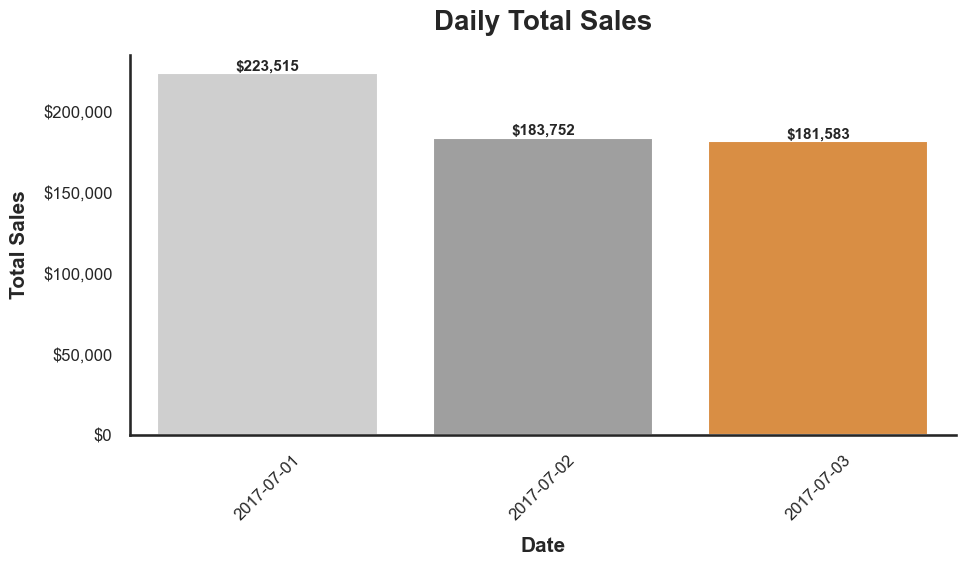

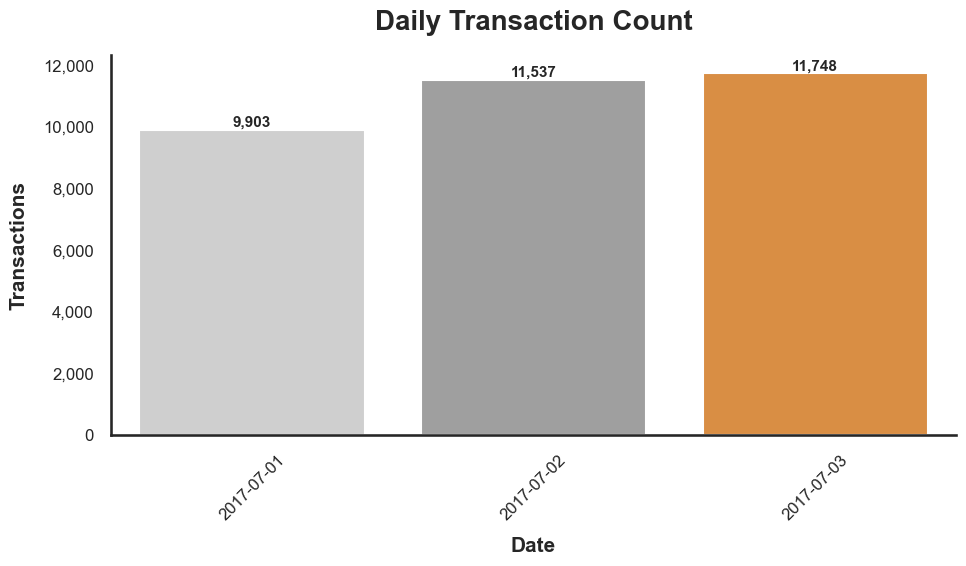

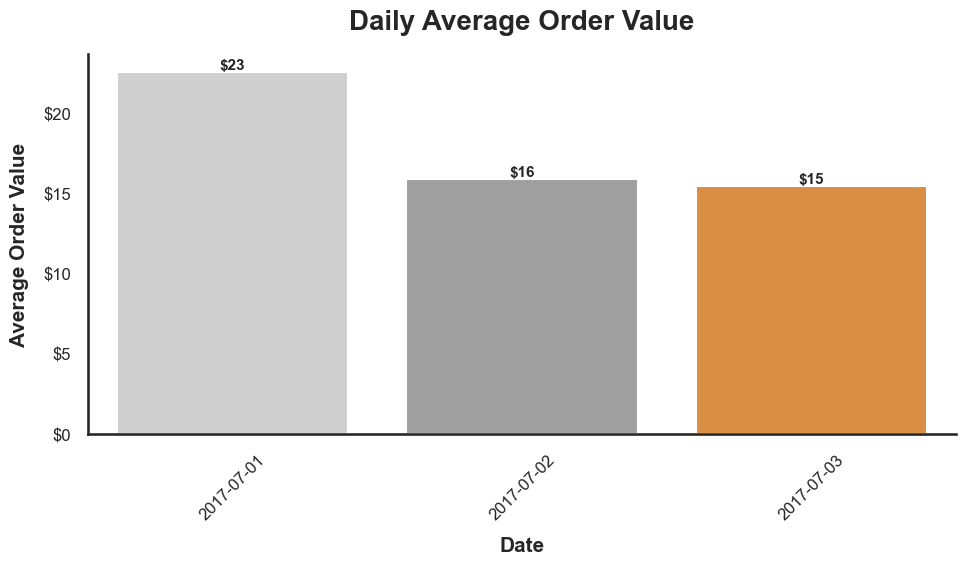

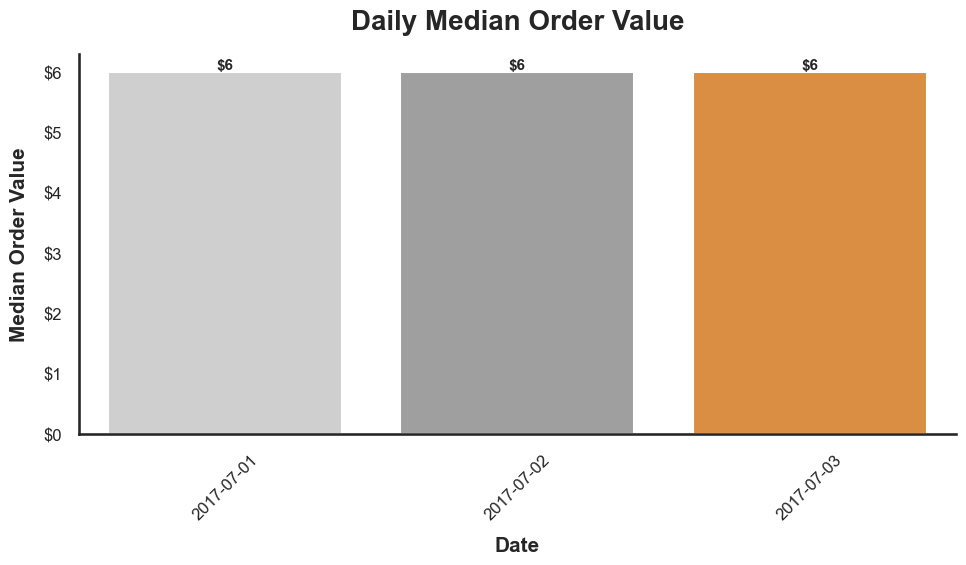

In [57]:
# ------------------------------------------------------------
# Daily totals, volume, average, and median
# ------------------------------------------------------------

plot_daily_bar(
    data=daily_summary,
    y_col="total_sales",
    title="Daily Total Sales",
    y_label="Total Sales",
    money_axis=True
)

plot_daily_bar(
    data=daily_summary,
    y_col="transactions",
    title="Daily Transaction Count",
    y_label="Transactions"
)

plot_daily_bar(
    data=daily_summary,
    y_col="average_order_value",
    title="Daily Average Order Value",
    y_label="Average Order Value",
    money_axis=True
)

plot_daily_bar(
    data=daily_summary,
    y_col="median_order_value",
    title="Daily Median Order Value",
    y_label="Median Order Value",
    money_axis=True
)

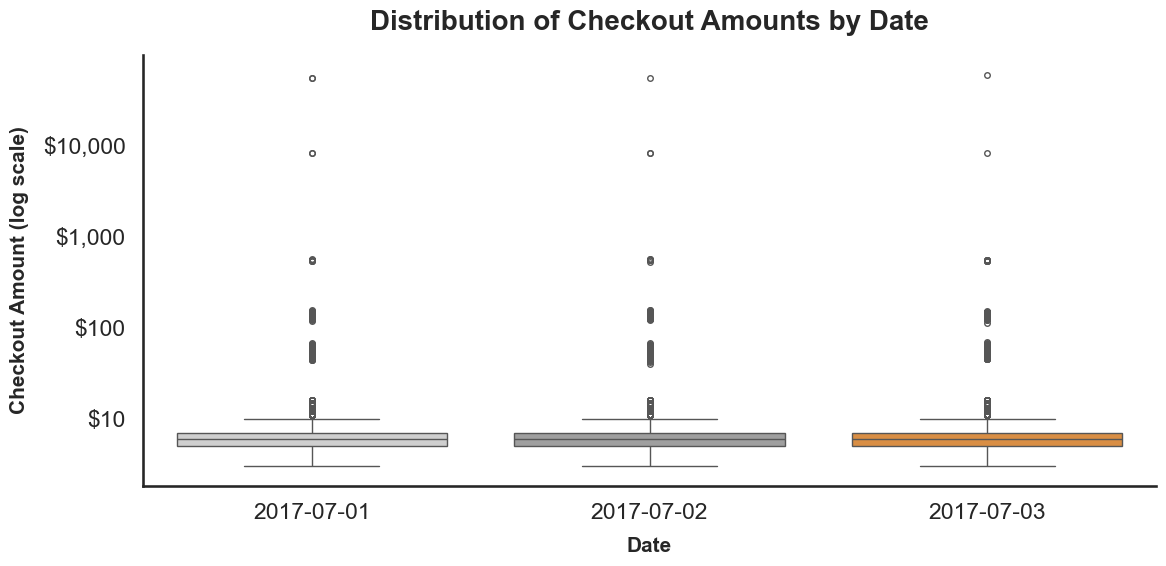

In [58]:
# ------------------------------------------------------------
# Checkout amount distribution by date
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

date_order = sorted(df["date"].unique())
palette = [
    TARGET_COLOR if date == TARGET_DATE else GREY_COLORS[i % len(GREY_COLORS)]
    for i, date in enumerate(date_order)
]

ax = sns.boxplot(
    data=df,
    x="date",
    y="checkout_amount",
    hue="date",
    order=date_order,
    palette=palette,
    legend=False,
    fliersize=4
)

plt.yscale("log")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))

plt.title("Distribution of Checkout Amounts by Date", **TITLE_STYLE)
plt.xlabel("Date", **AXIS_LABEL_STYLE)
plt.ylabel("Checkout Amount (log scale)", **AXIS_LABEL_STYLE)

plt.grid(False)
sns.despine()
plt.tight_layout()
plt.show()

<div style="background-color:#f7f7f7; padding:18px; border-left:6px solid #f28e2b; border-radius:6px;">

### Answer Summary

Average order value is useful, but it is not the right metric to use by itself.

In this data, the median checkout value is stable at `$6.00` across all three days, while average order value changes more noticeably. That tells me the average is being influenced by the upper tail of the checkout distribution rather than reflecting a major shift in the typical transaction.

For a daily sales report, I would include **total sales, transaction count, average order value, median order value, high-value transaction counts, negative/unusual checkout counts, and website/app-version breakdowns**. Together, these metrics give a much clearer picture than average sales value alone.

</div>

### Why average sales value is not enough

I interpret “average sales value” as average checkout value per transaction.

Average order value is useful because it summarizes revenue per transaction. However, it is sensitive to outliers. In this dataset, a small number of very large checkout amounts can pull the average upward even when the typical checkout amount has not changed.

That is why the median matters here. The median checkout value stays at `$6.00` across all three days, while the average order value ranges from `$15.46` to `$22.57`.

So the average is not wrong, but it is incomplete. A change in average order value could reflect a real change in purchasing behavior, or it could be driven by a small number of unusually large transactions.

### Metrics I would include

| Metric | Why I would report it |
|:---|:---|
| **Total sales** | Shows the overall revenue for the day. |
| **Transaction count** | Shows whether revenue changed because of purchase volume. |
| **Average order value** | Useful revenue-per-transaction metric, but sensitive to large transactions. |
| **Median order value** | Better representation of a typical checkout when the distribution is skewed. |
| **Min/max checkout value** | Quickly surfaces unusual negative or very large transactions. |
| **High-value transaction count and contribution** | Shows whether daily totals are being driven by a few unusually large checkouts. |
| **Negative checkout count and contribution** | Flags possible refunds, corrections, promotions, or logging issues. |
| **Website breakdown** | Helps determine whether a pattern is system-wide or isolated to one website. |
| **App-version breakdown** | Helps determine whether behavior changes around the app update. |

### Conclusion

Average order value should be included, but it should not be the primary metric by itself.

Because checkout amounts are skewed, the average can move even when the typical checkout value stays the same. In this data, the stable `$6.00` median is an important clue that the average is being affected by larger transactions rather than broad changes in normal checkout behavior.

A better daily report would pair average order value with total sales, transaction count, median order value, and anomaly checks. When diagnosing a specific date like July 3, I would also break those metrics down by website and app version.

<div style="background-color:#fff3cd; padding:16px; border-left:6px solid #f0ad4e; border-radius:6px;">

## Question 3: What information can you extract from the URLs? Can you infer all product prices? Is there any other information that you believe would be useful to understand what is going on?

</div>

The URLs contain more than just website location. The query strings appear to encode the cart contents for each transaction, which makes them useful for understanding products, quantities, cart size, and unusual checkout behavior.

Before inferring prices, I first parse the URLs into transaction-product rows and inspect whether the parsed cart information behaves consistently.

In [59]:
# ------------------------------------------------------------
# Inspect URL examples by website
# ------------------------------------------------------------

for website_id in sorted(df["website_id"].dropna().unique()):
    print(f"\nWebsite ID: {website_id}")
    print("=" * 100)
    
    examples = (
        df[df["website_id"] == website_id]
        [["url", "checkout_amount", "date", "app_version"]]
        .drop_duplicates("url")
        .head(3)
    )
    
    for _, row in examples.iterrows():
        print(f"Date: {row['date']} | App: {row['app_version']} | Amount: ${row['checkout_amount']:,.2f}")
        print(row["url"])
        print("-" * 100)


Website ID: 123
Date: 2017-07-01 | App: 1.1 | Amount: $6.00
http://www.example.com/store/?Natal+Orange=1
----------------------------------------------------------------------------------------------------
Date: 2017-07-01 | App: 1.1 | Amount: $5.00
http://www.example.com/store/?Black%2FWhite+Pepper=1
----------------------------------------------------------------------------------------------------
Date: 2017-07-01 | App: 1.1 | Amount: $12.00
http://www.example.com/store/?Ume=1&Natal+Orange=1
----------------------------------------------------------------------------------------------------

Website ID: 124
Date: 2017-07-01 | App: 1.1 | Amount: $6.00
http://xyz.com/checkout?Bignay=1
----------------------------------------------------------------------------------------------------
Date: 2017-07-01 | App: 1.1 | Amount: $6.00
http://xyz.com/checkout?Ume=1
----------------------------------------------------------------------------------------------------
Date: 2017-07-01 | App: 1.1 

In [60]:
# ------------------------------------------------------------
# Parse product names and quantities from URL query strings
# ------------------------------------------------------------

from urllib.parse import urlparse, parse_qs, unquote_plus

def parse_url_products(url):
    """
    Parse product names and quantities from a checkout URL.

    Returns a dictionary:
        {product_name: quantity}
    """
    if pd.isna(url):
        return {}
    
    parsed = urlparse(str(url))
    query = parsed.query
    
    if not query:
        return {}
    
    parsed_query = parse_qs(query, keep_blank_values=True)
    
    products = {}
    for raw_product, raw_quantity in parsed_query.items():
        product = unquote_plus(raw_product).strip()
        
        # parse_qs returns values as lists
        quantity_value = raw_quantity[0] if raw_quantity else None
        
        try:
            quantity = int(quantity_value)
        except (TypeError, ValueError):
            quantity = np.nan
        
        products[product] = quantity
    
    return products


df["url_domain"] = df["url"].apply(lambda x: urlparse(str(x)).netloc if pd.notna(x) else None)
df["url_path"] = df["url"].apply(lambda x: urlparse(str(x)).path if pd.notna(x) else None)
df["product_quantities"] = df["url"].apply(parse_url_products)

df["num_distinct_products"] = df["product_quantities"].apply(len)
df["total_product_quantity"] = df["product_quantities"].apply(
    lambda d: sum(q for q in d.values() if pd.notna(q))
)

df[
    [
        "url",
        "url_domain",
        "url_path",
        "product_quantities",
        "num_distinct_products",
        "total_product_quantity",
        "checkout_amount",
    ]
].head(10)

,url,url_domain,url_path,product_quantities,num_distinct_products,total_product_quantity,checkout_amount
0,http://xyz.com/checkout?Bignay=1,xyz.com,/checkout,{'Bignay': 1},1,1,6.0
1,http://xyz.com/checkout?Ume=1,xyz.com,/checkout,{'Ume': 1},1,1,6.0
2,http://xyz.com/checkout?Natal+Orange=1,xyz.com,/checkout,{'Natal Orange': 1},1,1,6.0
3,http://www.example.com/store/?Natal+Orange=1,www.example.com,/store/,{'Natal Orange': 1},1,1,6.0
4,http://xyz.com/checkout?Hazelnut=1,xyz.com,/checkout,{'Hazelnut': 1},1,1,4.0
5,http://xyz.com/checkout?Round+Kumquat=1,xyz.com,/checkout,{'Round Kumquat': 1},1,1,7.0
6,http://xyz.com/checkout?Ylang-ylang=1,xyz.com,/checkout,{'Ylang-ylang': 1},1,1,5.0
7,http://www.example.com/store/?Black%2FWhite+Pepper=1,www.example.com,/store/,{'Black/White Pepper': 1},1,1,5.0
8,http://www.example.com/store/?Ume=1&Natal+Orange=1,www.example.com,/store/,"{'Ume': 1, 'Natal Orange': 1}",2,2,12.0
9,http://xyz.com/checkout?Round+Kumquat=1,xyz.com,/checkout,{'Round Kumquat': 1},1,1,7.0


In [61]:
# ------------------------------------------------------------
# Create one row per transaction-product pair
# ------------------------------------------------------------

product_rows = []

for idx, row in df.iterrows():
    for product, quantity in row["product_quantities"].items():
        product_rows.append({
            "transaction_index": idx,
            "timestamp": row["timestamp"],
            "date": row["date"],
            "hour": row["hour"],
            "website_id": row["website_id"],
            "customer_id": row["customer_id"],
            "app_version": row["app_version"],
            "checkout_amount": row["checkout_amount"],
            "url_domain": row["url_domain"],
            "url_path": row["url_path"],
            "product": product,
            "quantity": quantity,
            "url": row["url"],
        })

product_df = pd.DataFrame(product_rows)

print(f"Product-level rows: {len(product_df):,}")
print(f"Unique products: {product_df['product'].nunique():,}")

product_df.head(10)

Product-level rows: 46,336
Unique products: 11


,transaction_index,timestamp,date,hour,website_id,customer_id,app_version,checkout_amount,url_domain,url_path,product,quantity,url
0,0,2017-07-01 07:00:05+00:00,2017-07-01,7,124,9221,1.1,6.0,xyz.com,/checkout,Bignay,1.0,http://xyz.com/checkout?Bignay=1
1,1,2017-07-01 07:00:14+00:00,2017-07-01,7,124,1639,1.1,6.0,xyz.com,/checkout,Ume,1.0,http://xyz.com/checkout?Ume=1
2,2,2017-07-01 00:00:15+00:00,2017-07-01,0,124,8272,1.1,6.0,xyz.com,/checkout,Natal Orange,1.0,http://xyz.com/checkout?Natal+Orange=1
3,3,2017-07-01 00:00:18+00:00,2017-07-01,0,123,6921,1.1,6.0,www.example.com,/store/,Natal Orange,1.0,http://www.example.com/store/?Natal+Orange=1
4,4,2017-07-01 00:00:19+00:00,2017-07-01,0,124,9219,1.1,4.0,xyz.com,/checkout,Hazelnut,1.0,http://xyz.com/checkout?Hazelnut=1
5,5,2017-07-01 00:00:28+00:00,2017-07-01,0,124,8451,1.1,7.0,xyz.com,/checkout,Round Kumquat,1.0,http://xyz.com/checkout?Round+Kumquat=1
6,6,2017-07-01 00:00:32+00:00,2017-07-01,0,124,6079,1.1,5.0,xyz.com,/checkout,Ylang-ylang,1.0,http://xyz.com/checkout?Ylang-ylang=1
7,7,2017-07-01 07:00:34+00:00,2017-07-01,7,123,5267,1.1,5.0,www.example.com,/store/,Black/White Pepper,1.0,http://www.example.com/store/?Black%2FWhite+Pepper=1
8,8,2017-07-01 07:00:37+00:00,2017-07-01,7,123,10151,1.1,12.0,www.example.com,/store/,Ume,1.0,http://www.example.com/store/?Ume=1&Natal+Orange=1
9,8,2017-07-01 07:00:37+00:00,2017-07-01,7,123,10151,1.1,12.0,www.example.com,/store/,Natal Orange,1.0,http://www.example.com/store/?Ume=1&Natal+Orange=1


In [62]:
# ------------------------------------------------------------
# Product-level summary
# ------------------------------------------------------------

product_summary = (
    product_df
    .groupby("product")
    .agg(
        transactions=("transaction_index", "nunique"),
        total_quantity=("quantity", "sum"),
        avg_quantity=("quantity", "mean"),
        min_quantity=("quantity", "min"),
        max_quantity=("quantity", "max"),
        avg_checkout_amount=("checkout_amount", "mean"),
        median_checkout_amount=("checkout_amount", "median"),
        websites=("website_id", "nunique"),
        app_versions=("app_version", "nunique"),
    )
    .reset_index()
    .sort_values(["transactions", "total_quantity"], ascending=False)
)

product_summary.head(20)

,product,transactions,total_quantity,avg_quantity,min_quantity,max_quantity,avg_checkout_amount,median_checkout_amount,websites,app_versions
5,Natal Orange,4755,9633.0,2.025868,1.0,999.0,70.758991,6.0,2,2
1,Black/White Pepper,4733,9766.0,2.063385,1.0,1049.0,70.028101,5.0,2,2
7,Round Kumquat,4666,9615.0,2.060652,1.0,1011.0,72.442778,7.0,2,2
6,Prairie Potato,4652,9576.0,2.058469,1.0,1013.0,69.417025,3.0,2,2
0,Bignay,4625,9547.0,2.064216,1.0,1003.0,84.893405,6.0,2,2
4,Mabolo,4611,9649.0,2.092605,1.0,1059.0,73.612232,8.0,2,2
9,Ylang-ylang,4596,9588.0,2.086162,1.0,1035.0,71.160574,5.0,2,2
2,European Grape,4585,9567.0,2.086587,1.0,1011.0,71.872192,5.0,2,2
3,Hazelnut,4580,9667.0,2.110699,1.0,1015.0,70.983843,4.0,2,2
8,Ume,4532,9617.0,2.122021,1.0,1008.0,73.780450,6.0,2,2


In [63]:
# Inspect rows where the parsed product is "error"

error_product_rows = product_df[
    product_df["product"].str.lower() == "error"
].copy()

error_product_rows[
    [
        "timestamp",
        "date",
        "hour",
        "website_id",
        "customer_id",
        "app_version",
        "checkout_amount",
        "product",
        "quantity",
        "url",
    ]
]

,timestamp,date,hour,website_id,customer_id,app_version,checkout_amount,product,quantity,url
37854,2017-07-03 07:59:32+00:00,2017-07-03,7,124,8553,1.2,60000.0,error,NaN,http://xyz.com/checkout?Bignay=1&error=True


### Important Anomaly: Malformed URL Behavior

One transaction contains an error-like URL token and is associated with an extreme checkout amount. This matters because product price inference depends on the assumption that the URL accurately represents the cart.

If a URL contains an error token, malformed query string, or incomplete cart information, then the checkout amount should not be used as normal evidence for product pricing. In this case, the row is useful as an anomaly flag, but not as a reliable product-price observation.

<div style="background-color:#f7f7f7; padding:18px; border-left:6px solid #f28e2b; border-radius:6px;">

### Answer Summary

The URLs are useful because the query strings encode cart contents as product/count pairs. From them, I can extract product names, quantities, cart size, product combinations, website/domain patterns, and malformed or unusual checkout behavior.

Product prices can be inferred for normal cart rows, especially from single-product transactions where unit price is directly observable. These inferred prices appear consistent across both websites for the normal products.

However, I would not infer prices blindly from every URL. At least one row parses as an `error` product and is associated with an extreme `$60,000.00` checkout amount. That row should be treated as an anomaly, not as reliable product-price evidence.

</div>

### Product Price Inference Approach

Single-product carts are the most reliable starting point because the unit price can be calculated directly. Multi-product carts are more complicated because the checkout amount is a combined total across several products.

The URL query strings appear to encode cart contents as product/count pairs. This means each transaction can be treated as a small cart equation:

`checkout_amount = quantity_1 × price_1 + quantity_2 × price_2 + ...`

For price inference, I exclude malformed `error` rows and negative checkout amounts. The negative transactions may be valid adjustments or refunds, but they should not be used as normal product-price evidence without more context.

I do not want to assume upfront that product prices are identical across websites, so I start by checking observed unit prices from single-product carts, grouped by website and product.

In [64]:
# ------------------------------------------------------------
# Prepare product/cart rows for price inference
# ------------------------------------------------------------

# Price inference should only use rows where the URL was parsed cleanly
# and the checkout amount represents a normal positive purchase.
valid_product_rows = product_df.dropna(subset=["product", "quantity"]).copy()

valid_product_rows["product"] = valid_product_rows["product"].astype("string")
valid_product_rows["quantity"] = pd.to_numeric(
    valid_product_rows["quantity"],
    errors="coerce"
)

valid_product_rows = valid_product_rows.dropna(subset=["quantity"]).copy()

# Exclude malformed/error-like URL tokens from product price inference.
valid_product_rows = valid_product_rows[
    valid_product_rows["product"].str.lower() != "error"
].copy()

# Negative checkout amounts may be refunds, corrections, promotions, or logging issues.
# They should not be used as normal product-price evidence without more context.
valid_product_rows_positive = valid_product_rows[
    valid_product_rows["checkout_amount"] > 0
].copy()

# Identify carts with exactly one distinct parsed product.
cart_product_counts = (
    valid_product_rows_positive
    .groupby("transaction_index")
    .agg(
        distinct_products=("product", "nunique"),
        total_items=("quantity", "sum"),
        checkout_amount=("checkout_amount", "first"),
        website_id=("website_id", "first"),
        date=("date", "first"),
        app_version=("app_version", "first"),
        url=("url", "first"),
    )
    .reset_index()
)

single_product_transaction_indices = cart_product_counts.loc[
    cart_product_counts["distinct_products"] == 1,
    "transaction_index"
]

single_product_rows = valid_product_rows_positive[
    valid_product_rows_positive["transaction_index"].isin(single_product_transaction_indices)
].copy()

# For single-product carts, unit price can be observed directly:
# checkout_amount = quantity * unit_price
single_product_rows["observed_unit_price"] = (
    single_product_rows["checkout_amount"] / single_product_rows["quantity"]
)

single_product_price_summary = (
    single_product_rows
    .groupby(["website_id", "product"])
    .agg(
        observed_transactions=("transaction_index", "nunique"),
        min_observed_unit_price=("observed_unit_price", "min"),
        median_observed_unit_price=("observed_unit_price", "median"),
        max_observed_unit_price=("observed_unit_price", "max"),
    )
    .reset_index()
    .sort_values(["product", "website_id"])
)

single_product_price_summary

,website_id,product,observed_transactions,min_observed_unit_price,median_observed_unit_price,max_observed_unit_price
0,123,Bignay,1474,6.0,6.0,6.0
10,124,Bignay,1428,6.0,6.0,60000.0
1,123,Black/White Pepper,1462,5.0,5.0,5.0
11,124,Black/White Pepper,1480,5.0,5.0,5.0
2,123,European Grape,1433,5.0,5.0,5.0
12,124,European Grape,1418,5.0,5.0,5.0
3,123,Hazelnut,1392,4.0,4.0,4.0
13,124,Hazelnut,1419,4.0,4.0,4.0
4,123,Mabolo,1448,8.0,8.0,8.0
14,124,Mabolo,1442,8.0,8.0,8.0


### What the Single-Product Carts Suggest

Single-product carts provide the cleanest evidence for product prices because the checkout amount can be divided directly by the item quantity.

For the normal parsed products, the observed unit prices are consistent within each product, and they appear consistent across the two websites. This suggests the URLs can be used to infer product prices, at least for ordinary transactions with valid product/count pairs.

The important exception is the malformed/error-like URL row tied to the `$60,000.00` checkout amount. That transaction should be treated separately from normal product-price inference.

### Other Useful Information from the URLs

| URL-derived field | Why it is useful |
|:---|:---|
| **Domain / website path** | Helps separate behavior across the two website implementations. |
| **Product names** | Allows product mix to be compared across dates, websites, and app versions. |
| **Product quantities** | Allows cart size and item-count behavior to be analyzed. |
| **Distinct products per cart** | Helps distinguish simple single-product purchases from larger multi-product carts. |
| **Malformed or error-like URL tokens** | Helps identify transactions that should be excluded from normal product-price inference. |
| **Product combinations** | Helps identify common bundles or cart patterns that may affect checkout value. |

### Conclusion

The URLs are one of the most useful fields in the dataset because they provide transaction-level cart information that is not available from the checkout amount alone. By parsing the query strings, I can extract product names, quantities, cart size, product combinations, website/domain patterns, and malformed or error-like behavior.

For normal parsed rows, product prices can be inferred most cleanly from single-product carts. These carts provide direct evidence of unit price because the checkout amount can be divided by the item quantity. Based on those transactions, the normal product prices appear stable and consistent across both websites.

However, price inference should not be applied blindly to every row. The malformed `error` row tied to the `$60,000.00` checkout amount is a clear example of why the URLs need to be validated before treating them as reliable cart data. Negative checkout amounts should also be handled separately, since they may represent refunds, adjustments, promotions, or logging issues rather than normal product purchases.

Overall, the URL-derived fields are useful for understanding whether July 3 looks unusual because of product mix, cart size, website behavior, or data/system anomalies. They also provide important context for interpreting large checkout values and deciding which transactions should be included in normal product-price analysis.

<div style="background-color:#fff3cd; padding:16px; border-left:6px solid #f0ad4e; border-radius:6px;">

## Question 4: Are there any interesting purchasing combinations, events, or metrics that are worth reporting and displaying? What information should the analyst know about the system that you’ve uncovered?

</div>

To answer this, I look at both purchasing behavior and system/data-quality behavior. The URL-derived cart fields make it possible to examine product combinations, cart size, and product mix. The earlier checks also surfaced several system-level issues that are important context for interpreting daily sales.

In [65]:
# ------------------------------------------------------------
# Common product combinations and product-pair co-occurrence
# ------------------------------------------------------------

# from itertools import combinations

# Keep only valid product rows for cart-level analysis
valid_cart_product_rows = product_df[
    (product_df["product"].notna()) &
    (product_df["product"].str.lower() != "error") &
    (product_df["quantity"].notna()) &
    (product_df["quantity"] > 0)
].copy()

# One row per transaction/cart
cart_products = (
    valid_cart_product_rows
    .groupby(["transaction_index", "date"])
    .agg(
        products=("product", lambda x: tuple(sorted(set(x)))),
        distinct_products=("product", "nunique"),
        checkout_amount=("checkout_amount", "first"),
        total_quantity=("quantity", "sum"),
        website_id=("website_id", "first"),
        app_version=("app_version", "first"),
    )
    .reset_index()
)

total_carts = cart_products["transaction_index"].nunique()
multi_product_carts = cart_products.loc[
    cart_products["distinct_products"] > 1,
    "transaction_index"
].nunique()

# ------------------------------------------------------------
# Full-cart combinations
# ------------------------------------------------------------

product_combinations = (
    cart_products
    .groupby("products")
    .agg(
        transactions=("transaction_index", "nunique"),
        avg_checkout_amount=("checkout_amount", "mean"),
        median_checkout_amount=("checkout_amount", "median"),
        avg_total_quantity=("total_quantity", "mean"),
        days_observed=("date", "nunique"),
    )
    .reset_index()
    .sort_values("transactions", ascending=False)
)

product_combinations["product_combination"] = product_combinations["products"].apply(
    lambda x: " + ".join(x)
)

multi_product_combinations = product_combinations[
    product_combinations["products"].apply(len) > 1
].copy()

multi_product_combinations_display = (
    multi_product_combinations[
        [
            "product_combination",
            "transactions",
            "median_checkout_amount",
            "avg_checkout_amount",
            "avg_total_quantity",
            "days_observed",
        ]
    ]
    .head(15)
    .copy()
)

multi_product_combinations_display["median_checkout_amount"] = (
    multi_product_combinations_display["median_checkout_amount"].map("${:,.0f}".format)
)

multi_product_combinations_display["avg_checkout_amount"] = (
    multi_product_combinations_display["avg_checkout_amount"].map("${:,.2f}".format)
)

multi_product_combinations_display = multi_product_combinations_display.rename(columns={
    "product_combination": "Product Combination",
    "transactions": "Transactions",
    "median_checkout_amount": "Median Checkout",
    "avg_checkout_amount": "Average Checkout",
    "avg_total_quantity": "Average Total Quantity",
    "days_observed": "Days Observed",
})

multi_product_combinations_display

,Product Combination,Transactions,Median Checkout,Average Checkout,Average Total Quantity,Days Observed
5,Bignay + Black/White Pepper + European Grape + Hazelnut + Mabolo + Natal Orange + Prairie Potato + Round Kumquat + Ume + Ylang-ylang,161,$140,"$1,485.99",270.0,3
575,Prairie Potato + Ylang-ylang,71,$8,$8.00,2.0,3
412,Black/White Pepper + Hazelnut,70,$9,$9.00,2.0,3
1,Bignay + Black/White Pepper,70,$11,$11.00,2.0,3
550,Hazelnut + Prairie Potato,67,$7,$7.00,2.0,3
303,Bignay + Mabolo,66,$14,$14.00,2.0,3
529,Hazelnut + Mabolo,65,$12,$11.63,2.0,3
569,Natal Orange + Round Kumquat,64,$13,$13.00,2.0,3
564,Mabolo + Ylang-ylang,64,$13,$13.00,2.0,3
522,European Grape + Prairie Potato,64,$8,$8.00,2.0,3


In [66]:
top_combination = multi_product_combinations.iloc[0]

print("Most common multi-product cart:")
print(top_combination["product_combination"])
print()
print(f"Transactions: {top_combination['transactions']:,}")
print(f"Median checkout amount: ${top_combination['median_checkout_amount']:,.0f}")
print(f"Average checkout amount: ${top_combination['avg_checkout_amount']:,.2f}")
print(f"Average total quantity: {top_combination['avg_total_quantity']:,.1f}")
print(f"Days observed: {top_combination['days_observed']}")

Most common multi-product cart:
Bignay + Black/White Pepper + European Grape + Hazelnut + Mabolo + Natal Orange + Prairie Potato + Round Kumquat + Ume + Ylang-ylang

Transactions: 161
Median checkout amount: $140
Average checkout amount: $1,485.99
Average total quantity: 270.0
Days observed: 3


In [67]:
# ------------------------------------------------------------
# Inspect the most common multi-product cart (Sanity Check)
# ------------------------------------------------------------

top_combo = multi_product_combinations.iloc[0]
top_combo_products = top_combo["products"]

top_combo_transactions = cart_products[
    cart_products["products"] == top_combo_products
].copy()

print("Most common multi-product cart")
print("------------------------------")
print("Products:")
print(" + ".join(top_combo_products))
print()
print(f"Transactions: {top_combo_transactions['transaction_index'].nunique():,}")
print(f"Days observed: {top_combo_transactions['date'].nunique()}")
print(f"Median checkout: ${top_combo_transactions['checkout_amount'].median():,.0f}")
print(f"Average checkout: ${top_combo_transactions['checkout_amount'].mean():,.2f}")
print(f"Median total quantity: {top_combo_transactions['total_quantity'].median():,.0f}")
print(f"Average total quantity: {top_combo_transactions['total_quantity'].mean():,.1f}")
print(f"Max checkout: ${top_combo_transactions['checkout_amount'].max():,.0f}")
print(f"Max total quantity: {top_combo_transactions['total_quantity'].max():,.0f}")

Most common multi-product cart
------------------------------
Products:
Bignay + Black/White Pepper + European Grape + Hazelnut + Mabolo + Natal Orange + Prairie Potato + Round Kumquat + Ume + Ylang-ylang

Transactions: 161
Days observed: 3
Median checkout: $140
Average checkout: $1,485.99
Median total quantity: 25
Average total quantity: 270.0
Max checkout: $55,084
Max total quantity: 10,000


In [68]:
# ------------------------------------------------------------
# Where does the all-product cart occur?(Sanity Check)
# ------------------------------------------------------------

top_combo_breakdown = (
    top_combo_transactions
    .groupby(["date", "website_id", "app_version"])
    .agg(
        transactions=("transaction_index", "nunique"),
        median_checkout=("checkout_amount", "median"),
        avg_checkout=("checkout_amount", "mean"),
        median_quantity=("total_quantity", "median"),
        avg_quantity=("total_quantity", "mean"),
        max_checkout=("checkout_amount", "max"),
    )
    .reset_index()
    .sort_values(["date", "website_id", "app_version"])
)

top_combo_breakdown_display = top_combo_breakdown.copy()

for col in ["median_checkout", "avg_checkout", "max_checkout"]:
    top_combo_breakdown_display[col] = top_combo_breakdown_display[col].map("${:,.2f}".format)

for col in ["median_quantity", "avg_quantity"]:
    top_combo_breakdown_display[col] = top_combo_breakdown_display[col].map("{:,.1f}".format)

top_combo_breakdown_display = top_combo_breakdown_display.rename(columns={
    "date": "Date",
    "website_id": "Website ID",
    "app_version": "App Version",
    "transactions": "Transactions",
    "median_checkout": "Median Checkout",
    "avg_checkout": "Average Checkout",
    "median_quantity": "Median Quantity",
    "avg_quantity": "Average Quantity",
    "max_checkout": "Max Checkout",
})

top_combo_breakdown_display

,Date,Website ID,App Version,Transactions,Median Checkout,Average Checkout,Median Quantity,Average Quantity,Max Checkout
0,2017-07-01,123,1.1,26,$140.00,"$5,029.12",25.0,913.8,"$55,084.00"
1,2017-07-01,124,1.1,31,$140.00,$254.84,25.0,46.3,$573.00
2,2017-07-02,123,1.1,31,$137.00,"$2,482.81",25.0,451.6,"$55,002.00"
3,2017-07-02,124,1.1,25,$139.00,$188.80,25.0,34.0,$556.00
4,2017-07-03,123,1.1,13,$139.00,$860.77,25.0,155.8,"$8,326.00"
5,2017-07-03,123,1.2,12,$142.00,$208.33,25.0,37.5,$557.00
6,2017-07-03,124,1.1,7,$139.00,$254.57,25.0,46.4,$552.00
7,2017-07-03,124,1.2,16,$142.00,$214.31,25.0,39.1,$551.00


### Common Product Combinations

The most common multi-product cart is especially notable: it contains all 10 products and appears 161 times across all three days. Rather than looking like a typical two-product affinity pattern, this looks more like a full-catalog bundle, generated/test cart pattern, or system behavior worth monitoring.

The median checkout amount for this cart is $140, but the average checkout is much higher because some transactions have very large quantities. This means the analyst should not only report which items are purchased together, but should also monitor full-catalog carts, unusually high quantities, and whether these carts cluster by website, app version, or date.

### Pairwise Product Co-Occurrence

The full-cart combination table is useful because it reveals the repeated all-products cart pattern. I also looked at pairwise product co-occurrence because two-product relationships can provide a simpler way to monitor product relationships over time.

In this dataset, the pairwise view is not the strongest finding on its own. Many product pairs appear together at similar rates, partly because the repeated all-products cart contributes to many pair counts simultaneously. I therefore interpret the pairwise table as a diagnostic check rather than as strong evidence of specific product affinity.

In [69]:
# ------------------------------------------------------------
# Pairwise product co-occurrence
# ------------------------------------------------------------

from itertools import combinations

pair_rows = []

for _, row in cart_products.iterrows():
    products = list(row["products"])

    if len(products) < 2:
        continue

    for product_a, product_b in combinations(products, 2):
        pair_rows.append({
            "transaction_index": row["transaction_index"],
            "date": row["date"],
            "website_id": row["website_id"],
            "app_version": row["app_version"],
            "checkout_amount": row["checkout_amount"],
            "total_quantity": row["total_quantity"],
            "product_a": product_a,
            "product_b": product_b,
            "product_pair": f"{product_a} + {product_b}",
        })

product_pair_df = pd.DataFrame(pair_rows)

product_pair_summary = (
    product_pair_df
    .groupby(["product_a", "product_b", "product_pair"])
    .agg(
        transactions=("transaction_index", "nunique"),
        median_checkout_amount=("checkout_amount", "median"),
        avg_checkout_amount=("checkout_amount", "mean"),
        avg_total_quantity=("total_quantity", "mean"),
        days_observed=("date", "nunique"),
    )
    .reset_index()
    .sort_values("transactions", ascending=False)
)

product_pair_display = product_pair_summary.head(15).copy()

product_pair_display["median_checkout_amount"] = (
    product_pair_display["median_checkout_amount"].map("${:,.0f}".format)
)

product_pair_display["avg_checkout_amount"] = (
    product_pair_display["avg_checkout_amount"].map("${:,.2f}".format)
)

product_pair_display["avg_total_quantity"] = (
    product_pair_display["avg_total_quantity"].map("{:,.1f}".format)
)

product_pair_display = product_pair_display.rename(columns={
    "product_pair": "Product Pair",
    "transactions": "Transactions",
    "median_checkout_amount": "Median Checkout",
    "avg_checkout_amount": "Average Checkout",
    "avg_total_quantity": "Average Total Quantity",
    "days_observed": "Days Observed",
})

product_pair_display[
    [
        "Product Pair",
        "Transactions",
        "Median Checkout",
        "Average Checkout",
        "Average Total Quantity",
        "Days Observed",
    ]
]

,Product Pair,Transactions,Median Checkout,Average Checkout,Average Total Quantity,Days Observed
12,Black/White Pepper + Natal Orange,969,$57,$300.56,54.7,3
37,Natal Orange + Ume,964,$58,$302.98,55.0,3
19,European Grape + Natal Orange,963,$57,$302.29,55.0,3
13,Black/White Pepper + Prairie Potato,956,$55,$302.40,55.3,3
36,Natal Orange + Round Kumquat,955,$58,$305.11,55.3,3
35,Natal Orange + Prairie Potato,951,$56,$304.35,55.5,3
14,Black/White Pepper + Round Kumquat,951,$58,$305.92,55.6,3
15,Black/White Pepper + Ume,949,$57,$306.48,55.8,3
39,Prairie Potato + Round Kumquat,947,$57,$305.99,55.7,3
22,European Grape + Ume,945,$57,$307.90,56.0,3


### Product Co-Occurrence Heatmap

To make pairwise product relationships easier to scan, I also display the product-pair counts as a co-occurrence heatmap.

Each off-diagonal cell shows the number of carts containing both products. The diagonal shows the total number of carts containing that product at all.

In this dataset, the heatmap is not especially useful for identifying a small set of standout product pairs. Most product pairs occur together at fairly similar rates, and the repeated all-products cart pattern inflates many pairwise counts at the same time. As a result, the co-occurrence matrix mainly confirms that product-pair counts are broadly distributed rather than revealing one or two dominant two-product combinations.

This is still useful analytically because it shows that the most interesting combination finding is not a specific pair. Instead, the stronger finding is the repeated full-catalog cart pattern identified in the full-cart combination table.

In [70]:
# ------------------------------------------------------------
# Product co-occurrence matrix
# ------------------------------------------------------------

all_products = sorted(valid_cart_product_rows["product"].dropna().unique())

cooccurrence_matrix = pd.DataFrame(
    0,
    index=all_products,
    columns=all_products,
    dtype=int
)

for _, row in cart_products.iterrows():
    products = list(row["products"])

    for product_a in products:
        for product_b in products:
            cooccurrence_matrix.loc[product_a, product_b] += 1

cooccurrence_matrix

,Bignay,Black/White Pepper,European Grape,Hazelnut,Mabolo,Natal Orange,Prairie Potato,Round Kumquat,Ume,Ylang-ylang
Bignay,4625,944,895,898,916,926,938,919,928,878
Black/White Pepper,944,4733,938,939,917,969,956,951,949,897
European Grape,895,938,4585,894,872,963,944,938,945,907
Hazelnut,898,939,894,4580,899,938,933,930,923,883
Mabolo,916,917,872,899,4611,938,917,895,918,894
Natal Orange,926,969,963,938,938,4755,951,955,964,916
Prairie Potato,938,956,944,933,917,951,4652,947,933,908
Round Kumquat,919,951,938,930,895,955,947,4666,940,879
Ume,928,949,945,923,918,964,933,940,4532,919
Ylang-ylang,878,897,907,883,894,916,908,879,919,4596


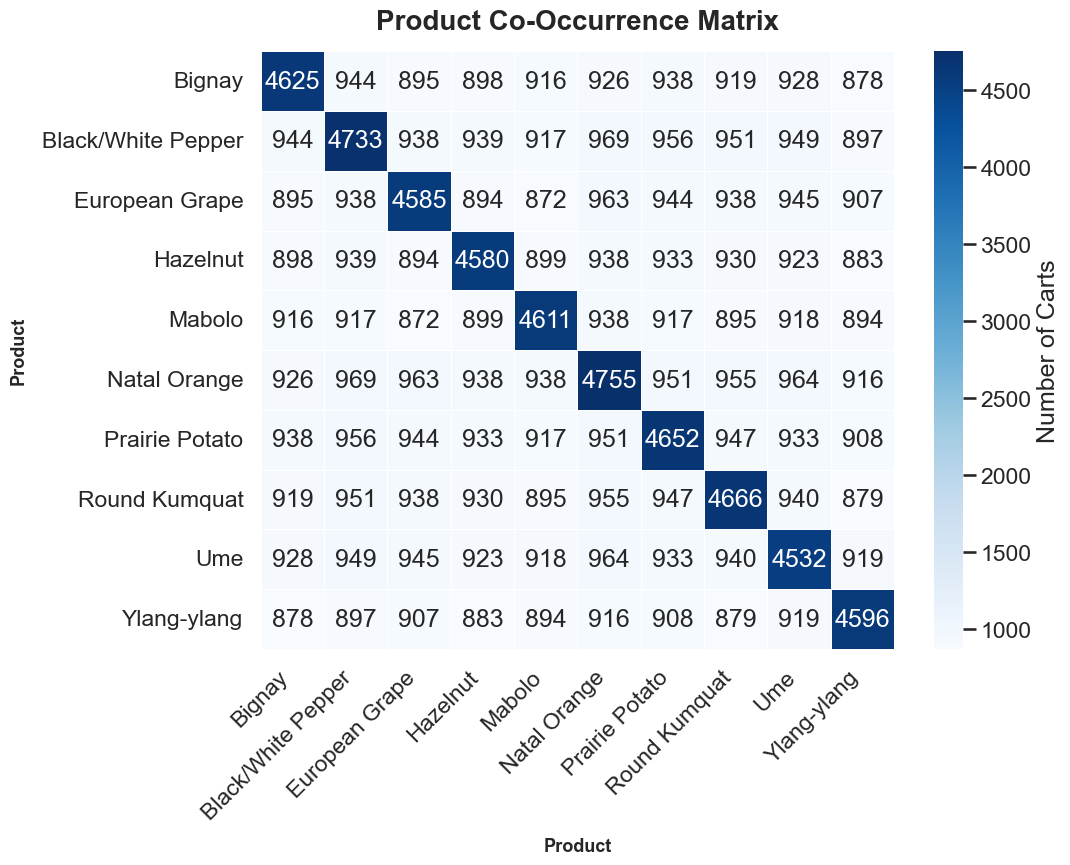

In [71]:
# ------------------------------------------------------------
# Visualize product co-occurrence matrix
# ------------------------------------------------------------

plt.figure(figsize=(11, 9))

ax = sns.heatmap(
    cooccurrence_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Number of Carts"}
)

ax.set_title(
    "Product Co-Occurrence Matrix",
    fontsize=20,
    fontweight="bold",
    pad=16
)

ax.set_xlabel(
    "Product",
    fontsize=13,
    fontweight="bold",
    labelpad=10
)

ax.set_ylabel(
    "Product",
    fontsize=13,
    fontweight="bold",
    labelpad=10
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [72]:
# ------------------------------------------------------------
# Cart size distribution
# ------------------------------------------------------------

cart_size_summary = (
    cart_products
    .groupby("distinct_products")
    .agg(
        transactions=("transaction_index", "nunique"),
        avg_checkout_amount=("checkout_amount", "mean"),
        median_checkout_amount=("checkout_amount", "median"),
        avg_total_quantity=("total_quantity", "mean"),
        median_total_quantity=("total_quantity", "median"),
        days_observed=("date", "nunique"),
    )
    .reset_index()
    .sort_values("distinct_products")
)

cart_size_summary

,distinct_products,transactions,avg_checkout_amount,median_checkout_amount,avg_total_quantity,median_total_quantity,days_observed
0,1,28868,7.637904,6.0,1.010496,1.0,3
1,2,2562,10.806011,11.0,2.000000,2.0,3
2,3,3,47.000000,49.0,10.000000,10.0,3
3,4,18,55.166667,55.0,10.000000,10.0,3
4,5,198,55.055556,55.0,10.000000,10.0,3
5,6,506,54.954545,55.0,10.000000,10.0,3
6,7,491,55.940937,55.0,10.122200,10.0,3
7,8,240,68.454167,56.0,12.500000,10.0,3
8,9,141,125.468085,134.0,22.978723,25.0,3
9,10,161,1485.993789,140.0,270.000000,25.0,3


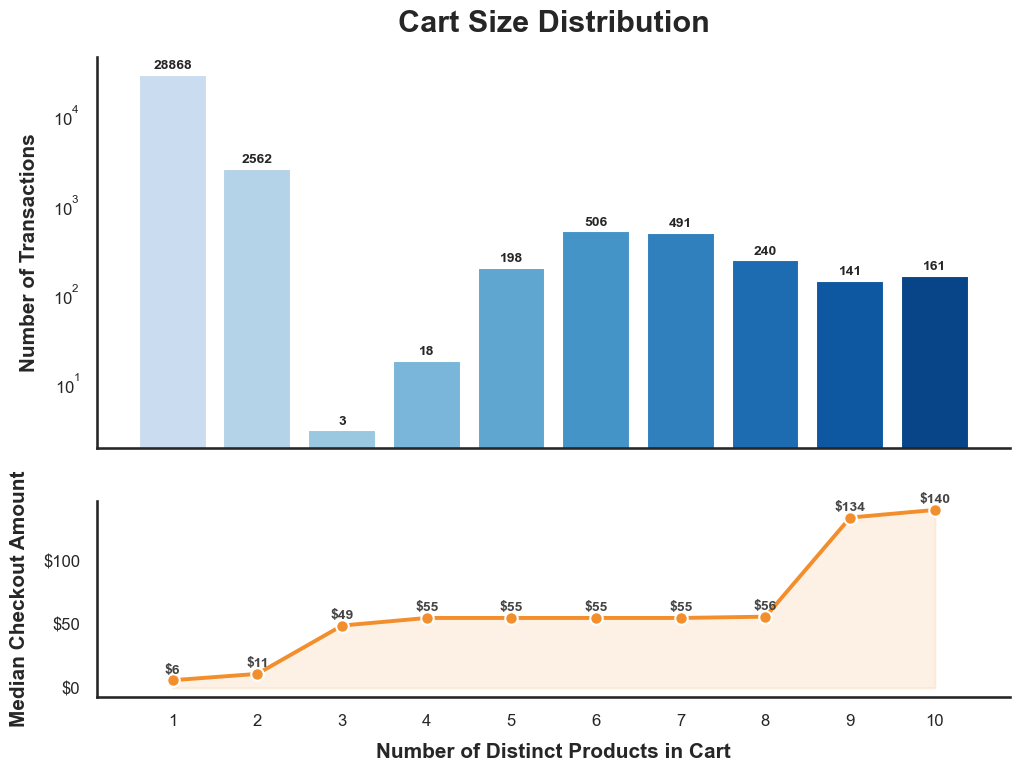

In [73]:
# ------------------------------------------------------------
# Cart size distribution visualization
# ------------------------------------------------------------

# Color setup
bar_colors = sns.color_palette("Blues", n_colors=len(cart_size_summary) + 2)[2:]
line_color = "#F28E2B"   # warm orange
marker_edge = "white"

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(11, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1], "hspace": 0.18}
)

# White background for cleaner look
fig.patch.set_facecolor("white")
ax1.set_facecolor("white")
ax2.set_facecolor("white")

# -----------------------------
# Top plot: transaction counts
# -----------------------------
bars = ax1.bar(
    cart_size_summary["distinct_products"],
    cart_size_summary["transactions"],
    color=bar_colors,
    edgecolor="white",
    linewidth=1.5
)

ax1.set_title(
    "Cart Size Distribution",
    fontsize=22,
    fontweight="bold",
    pad=18
)
ax1.set_ylabel(
    "Number of Transactions",
    fontsize=15,
    fontweight="bold",
    labelpad=10
)

# Log scale so smaller categories are visible
ax1.set_yscale("log")

ax1.tick_params(axis="x", labelsize=12)
ax1.tick_params(axis="y", labelsize=12)
ax1.grid(False)

# Light cleanup of spines
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# Labels above bars
for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height * 1.08,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# -----------------------------
# Bottom plot: median checkout
# -----------------------------
ax2.plot(
    cart_size_summary["distinct_products"],
    cart_size_summary["median_checkout_amount"],
    color=line_color,
    marker="o",
    linewidth=2.8,
    markersize=9,
    markerfacecolor=line_color,
    markeredgecolor=marker_edge,
    markeredgewidth=1.5
)

# Optional light fill under line
ax2.fill_between(
    cart_size_summary["distinct_products"],
    cart_size_summary["median_checkout_amount"],
    color=line_color,
    alpha=0.12
)

ax2.set_xlabel(
    "Number of Distinct Products in Cart",
    fontsize=15,
    fontweight="bold",
    labelpad=10
)
ax2.set_ylabel(
    "Median Checkout Amount",
    fontsize=15,
    fontweight="bold",
    labelpad=10
)

ax2.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax2.tick_params(axis="x", labelsize=12)
ax2.tick_params(axis="y", labelsize=12)
ax2.grid(False)

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

# Annotate the line values
for x, y in zip(
    cart_size_summary["distinct_products"],
    cart_size_summary["median_checkout_amount"]
):
    ax2.text(
        x,
        y + 3,
        f"${y:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#444444"
    )

# Make x ticks explicit integers
ax2.set_xticks(cart_size_summary["distinct_products"])

fig.subplots_adjust(
    top=0.90,
    bottom=0.10,
    left=0.12,
    right=0.95,
    hspace=0.22
)

plt.show()

### Cart Size Interpretation

Cart size is a useful purchasing metric to display. Most transactions are small/simple carts, which supports the product-price inference from single-product purchases.

Larger carts are much less common, but they have higher checkout values and can have an outsized effect on daily sales and average order value. For that reason, I would report cart size alongside daily sales totals rather than relying only on total sales or average order value.

### Product Mix by Day

I first look at product mix as daily product shares. The bar chart makes the overall distribution easier to interpret before moving into the heatmaps. In particular, it helps show what an approximately “even” product mix looks like across the available products.

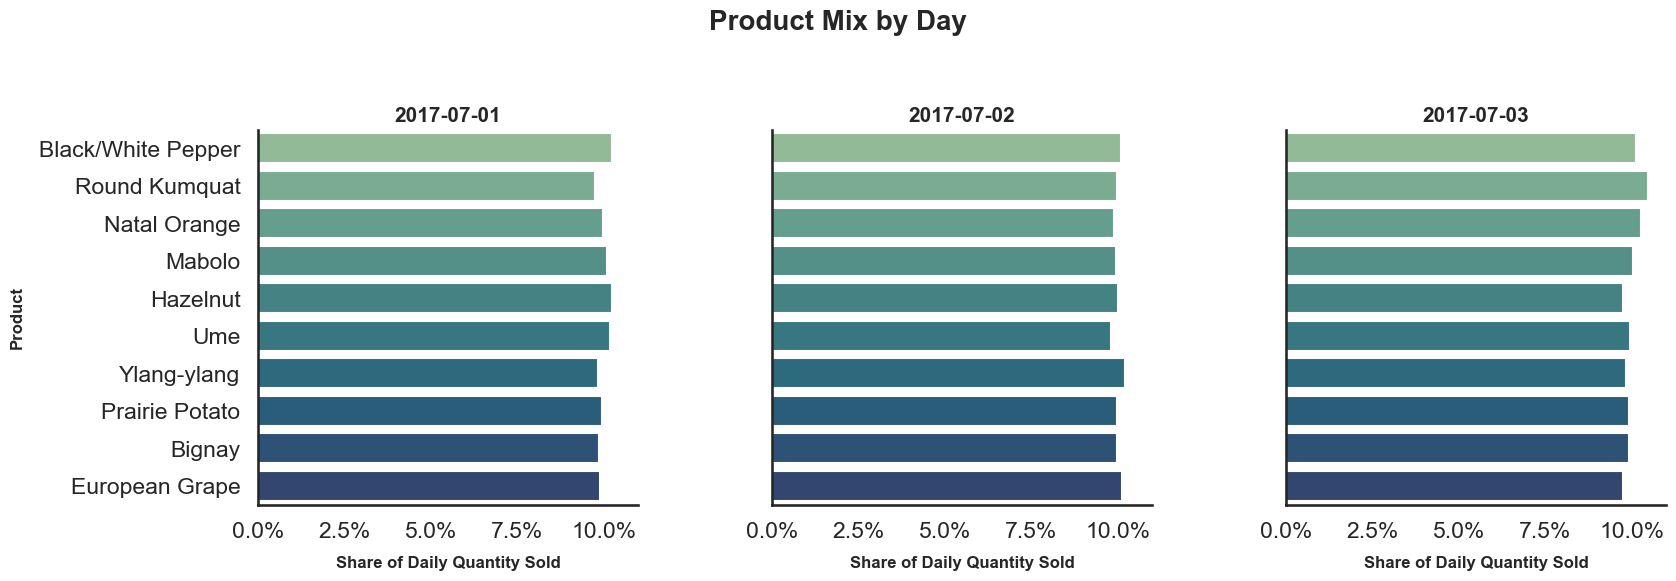

In [74]:
# ------------------------------------------------------------
# Product mix visualizations by day
# ------------------------------------------------------------

# Build daily product quantity table from parsed URL/product rows
daily_product_quantity = (
    product_df[
        (product_df["product"].notna()) &
        (product_df["product"].str.lower() != "error") &
        (product_df["quantity"].notna()) &
        (product_df["quantity"] > 0)
    ]
    .groupby(["date", "product"])
    .agg(
        total_quantity_sold=("quantity", "sum"),
        transaction_count=("transaction_index", "nunique")
    )
    .reset_index()
)

# Convert raw quantity to daily product share
daily_product_mix = daily_product_quantity.copy()

daily_product_mix["quantity_share"] = (
    daily_product_mix["total_quantity_sold"] /
    daily_product_mix.groupby("date")["total_quantity_sold"].transform("sum")
)

# Pivot for heatmaps
product_mix_pivot = (
    daily_product_mix
    .pivot_table(
        index="product",
        columns="date",
        values="quantity_share",
        aggfunc="sum"
    )
)

# Keep product order consistent: highest average share at top
product_order = (
    product_mix_pivot
    .mean(axis=1)
    .sort_values(ascending=False)
    .index
)

product_mix_pivot = product_mix_pivot.loc[product_order]


# ------------------------------------------------------------
# Plot 1: Small-multiple bar chart
# ------------------------------------------------------------

g = sns.catplot(
    data=daily_product_mix,
    kind="bar",
    x="quantity_share",
    y="product",
    hue="product",          # avoids seaborn FutureWarning
    col="date",
    order=product_order,
    hue_order=product_order,
    height=6,
    aspect=0.95,
    sharex=True,
    palette="crest",
    legend=False
)

g.set_titles("{col_name}", size=15, weight="bold")
g.set_axis_labels("Share of Daily Quantity Sold", "Product")

g.fig.subplots_adjust(wspace=0.35, top=0.78)

for ax in g.axes.flat:
    ax.grid(False)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_xlabel("Share of Daily Quantity Sold", fontweight="bold", fontsize=12, labelpad=10)
    ax.set_ylabel("Product", fontweight="bold", fontsize=12, labelpad=10)

g.fig.suptitle(
    "Product Mix by Day",
    fontweight="bold",
    fontsize=20
)

plt.show()



The heatmaps show the same product-mix information in a more compact form. The first heatmap shows each product’s share of daily quantity, while the second shows how far each product is from an even-share baseline.

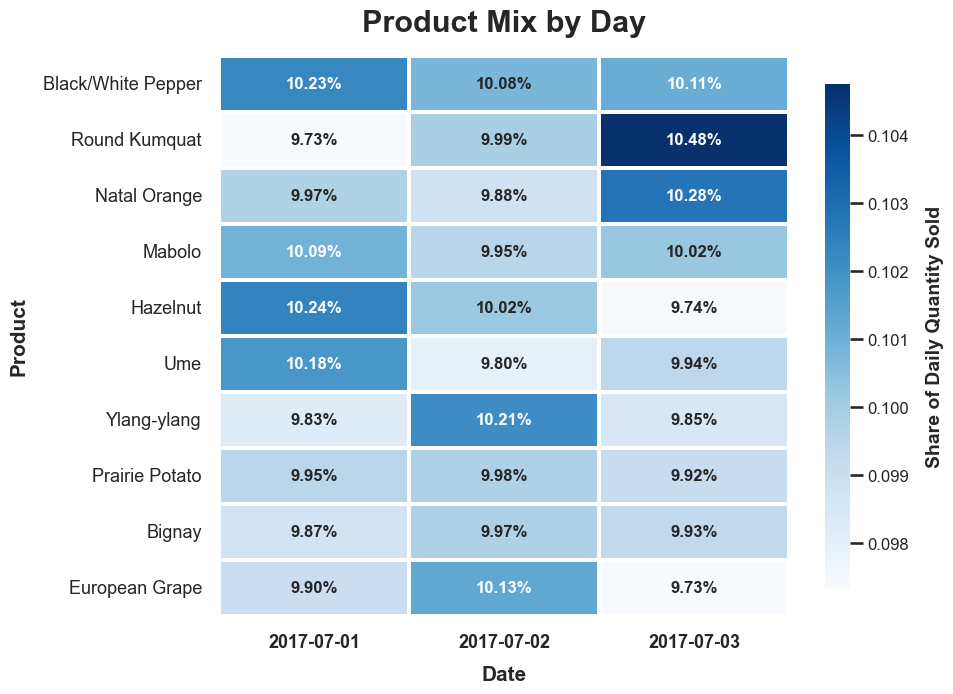

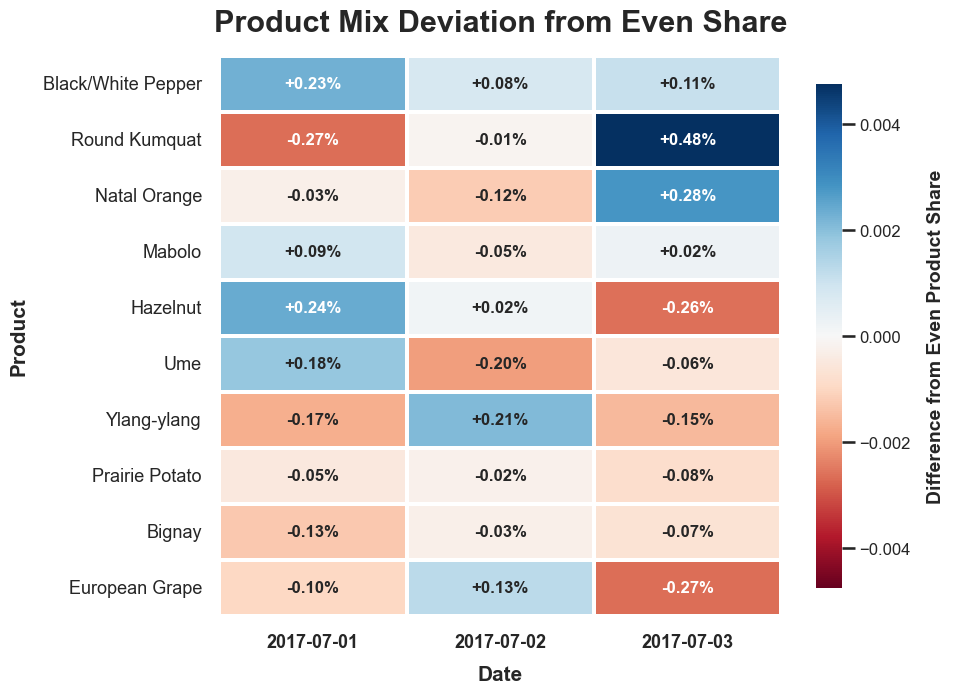

In [75]:

# ------------------------------------------------------------
# Plot 2: Product mix heatmap
# Larger shares are darker; smaller shares are lighter.
# ------------------------------------------------------------

plt.figure(figsize=(10, 7.5))

ax = sns.heatmap(
    product_mix_pivot,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    vmin=product_mix_pivot.min().min(),
    vmax=product_mix_pivot.max().max(),
    linewidths=1.5,
    linecolor="white",
    cbar_kws={
        "label": "Share of Daily Quantity Sold",
        "shrink": 0.9,
        "pad": 0.05
    },
    annot_kws={
        "fontsize": 12,
        "fontweight": "bold"
    }
)

plt.title(
    "Product Mix by Day",
    fontweight="bold",
    fontsize=22,
    pad=18
)
plt.xlabel(
    "Date",
    fontweight="bold",
    fontsize=15,
    labelpad=10
)
plt.ylabel(
    "Product",
    fontweight="bold",
    fontsize=15,
    labelpad=10
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0,
    fontsize=13,
    fontweight="bold"
)
ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=13
)

# Format colorbar label and ticks
cbar = ax.collections[0].colorbar
cbar.ax.set_ylabel(
    "Share of Daily Quantity Sold",
    fontsize=14,
    fontweight="bold",
    labelpad=12
)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout(pad=1.5)
plt.show()

# ------------------------------------------------------------
# Plot 3: Difference from even product share
# Since there are 10 products, an even share would be 10%.
# Positive values are above even share; negative values are below.
# ------------------------------------------------------------

expected_share = 1 / product_mix_pivot.shape[0]
product_mix_deviation = product_mix_pivot - expected_share

plt.figure(figsize=(10, 7.5))

max_abs_deviation = product_mix_deviation.abs().max().max()

ax = sns.heatmap(
    product_mix_deviation,
    annot=True,
    fmt="+.2%",
    cmap="RdBu",
    center=0,
    vmin=-max_abs_deviation,
    vmax=max_abs_deviation,
    linewidths=1.5,
    linecolor="white",
    cbar_kws={
        "label": "Difference from Even Product Share",
        "shrink": 0.9,
        "pad": 0.05
    },
    annot_kws={
        "fontsize": 12,
        "fontweight": "bold"
    }
)

plt.title(
    "Product Mix Deviation from Even Share",
    fontsize=22,
    fontweight="bold",
    pad=18
)
plt.xlabel(
    "Date",
    fontsize=15,
    fontweight="bold",
    labelpad=10
)
plt.ylabel(
    "Product",
    fontsize=15,
    fontweight="bold",
    labelpad=10
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0,
    fontsize=13,
    fontweight="bold"
)
ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=13
)

# Format colorbar label/ticks
cbar = ax.collections[0].colorbar
cbar.ax.set_ylabel(
    "Difference from Even Product Share",
    fontsize=14,
    fontweight="bold",
    labelpad=12
)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout(pad=1.5)
plt.show()

### Product Mix Interpretation

The product mix appears fairly balanced across the available days. There are small shifts in individual products, but no single product dominates the product mix in a way that would clearly explain the major sales-reporting differences.

This is useful because it suggests that product mix is not the main story. The more important findings are the repeated all-products cart pattern, checkout value distribution, anomalous transactions, malformed URL behavior, website/app-version behavior, and date-boundary handling.

<div style="background-color:#f7f7f7; padding:18px; border-left:6px solid #f28e2b; border-radius:6px;">

### Answer Summary

Yes. The URL-derived cart data uncovers several purchasing and system-level behaviors worth reporting.

The most notable purchasing combination is not a simple two-product pair. The most common multi-product cart contains all 10 products, appears 161 times across all three days, and has a median checkout of $140 but a much higher average checkout because some carts contain very large quantities. This pattern should be monitored as either meaningful full-catalog purchasing behavior or a possible generated/test/system pattern.

I also examined pairwise product co-occurrence. The pairwise table and heatmap show that many product pairs occur together at similar rates, which means the pairwise view is not especially diagnostic on its own. Because the repeated all-products cart contributes to many pair counts simultaneously, I would interpret pairwise co-occurrence alongside the full-cart combination table rather than treating it as strong evidence of product affinity.

The analyst should also monitor cart size, checkout amount distribution, high-value transactions, negative checkout amounts, malformed or error-like URLs, website ID, app version, and date-boundary/source-file handling. These system-level details affect how sales totals should be interpreted.

</div>

### What I Would Report or Display

| Area | What I would show | Why it matters |
|:---|:---|:---|
| **Daily sales overview** | Total sales, transaction count, average order value, median order value | Gives the basic revenue picture without relying on one metric alone. |
| **Checkout distribution** | Min/max values, high-value transaction counts, negative checkout counts | Flags outliers and unusual transaction values that can distort daily totals. |
| **Cart size** | Distinct products per cart, total quantity per cart, median checkout by cart size | Shows whether revenue is driven by typical carts or larger/more complex carts. |
| **Product mix** | Daily product share and product-mix deviation | Tests whether changes in daily sales are tied to what customers purchased. |
| **Product combinations** | Most common full-cart combinations, product-pair counts, and co-occurrence heatmap | Shows repeated all-product carts, bundle-like behavior, and whether pairwise relationships are actually informative. |
| **Website/app-version breakdowns** | Sales and anomalies by website ID and app version | Helps separate broad sales patterns from system-specific behavior. |
| **URL parsing validation** | Malformed/error-like URL rows and parse failure counts | Prevents bad URL rows from contaminating product-price inference. |

### Conclusion

The key finding from Question 4 is that the dataset should not be monitored only through daily sales totals. The URL-derived cart data reveals cart-level and system-level patterns that would otherwise be hidden.

The most important purchasing-combination finding is the repeated all-products cart. This is more informative than the pairwise co-occurrence heatmap, which shows broadly similar product-pair counts rather than a few standout pairings. In this case, the heatmap is useful mostly as a diagnostic check: it confirms that the strongest combination signal is at the full-cart level, not the two-product-pair level.

For ongoing reporting, I would track cart-size distribution, common full-cart combinations, product-pair counts, median checkout amount by cart size, high-value transactions, negative checkout amounts, malformed URLs, website ID, app version, and date-boundary/source-file handling.

Overall, URL parsing should be treated as a reporting layer, not just a cleaning step. It turns the data from daily sales totals into cart-level data that can support purchasing analysis, anomaly detection, and system monitoring.

<div style="background-color:#fff3cd; padding:16px; border-left:6px solid #f0ad4e; border-radius:6px;">

## Question 5: Can you predict the total sales number for 2017-07-04? How certain is the predicted number?

</div>

<div style="background-color:#f7f7f7; padding:18px; border-left:6px solid #f28e2b; border-radius:6px;">

The goal here is not to build a complicated forecasting model. With only three days of transaction data, any model would be fragile and would likely give a false sense of confidence.

Instead, I use a few simple baseline estimates and make the assumptions explicit. This gives a reasonable starting point while still being honest about the uncertainty, especially because the forecast date is `2017-07-04`, a U.S. holiday.

In [76]:
# ------------------------------------------------------------
# Question 5: Simple July 4 sales forecast baselines
# ------------------------------------------------------------

forecast_date = pd.to_datetime("2017-07-04").date()

# Daily summary used for forecasting
forecast_daily = (
    df.groupby("date")
    .agg(
        transactions=("checkout_amount", "size"),
        total_sales=("checkout_amount", "sum"),
        average_order_value=("checkout_amount", "mean"),
        median_order_value=("checkout_amount", "median"),
        min_order_value=("checkout_amount", "min"),
        max_order_value=("checkout_amount", "max"),
        negative_transactions=("checkout_amount", lambda x: (x < 0).sum()),
        negative_checkout_total=("checkout_amount", lambda x: x[x < 0].sum()),
    )
    .reset_index()
    .sort_values("date")
)

forecast_daily

,date,transactions,total_sales,average_order_value,median_order_value,min_order_value,max_order_value,negative_transactions,negative_checkout_total
0,2017-07-01,9903,223515.0,22.570433,6.0,0.0,55084.0,0,0.0
1,2017-07-02,11537,183752.0,15.927191,6.0,3.0,55002.0,0,0.0
2,2017-07-03,11748,181583.0,15.456503,6.0,-12.0,60000.0,17,-204.0


### Simple Forecast Baselines

I estimate July 4 sales using several simple baselines:

| Method | What it assumes |
|:---|:---|
| **Prior-day forecast** | July 4 looks like July 3. |
| **Recent 2-day average** | July 4 looks like the average of July 2 and July 3. |
| **Transaction count × recent AOV** | July 4 has a similar number of transactions and average order value as the recent period. |
| **Negative-value adjustment scenario** | July 3 would be slightly higher if the repeated `-12` transactions were sign errors. |

None of these methods is “the answer” by itself. I use them as a set of simple reference points, then choose a point estimate near the middle of the reasonable baselines.

In [77]:
# ------------------------------------------------------------
# Forecast candidates
# ------------------------------------------------------------

july_02 = forecast_daily.loc[
    forecast_daily["date"] == pd.to_datetime("2017-07-02").date()
].iloc[0]

july_03 = forecast_daily.loc[
    forecast_daily["date"] == pd.to_datetime("2017-07-03").date()
].iloc[0]


# 1. Prior-day baseline: July 4 looks like July 3
prior_day_forecast = july_03["total_sales"]


# 2. Recent average: July 4 looks like the average of July 2 and July 3
recent_2_day_average = forecast_daily[
    forecast_daily["date"].isin([
        pd.to_datetime("2017-07-02").date(),
        pd.to_datetime("2017-07-03").date()
    ])
]["total_sales"].mean()


# 3. Transaction-based baseline:
# Use recent average transaction count and recent average order value.
recent_avg_transactions = forecast_daily[
    forecast_daily["date"].isin([
        pd.to_datetime("2017-07-02").date(),
        pd.to_datetime("2017-07-03").date()
    ])
]["transactions"].mean()

recent_avg_order_value = forecast_daily[
    forecast_daily["date"].isin([
        pd.to_datetime("2017-07-02").date(),
        pd.to_datetime("2017-07-03").date()
    ])
]["average_order_value"].mean()

transaction_based_forecast = recent_avg_transactions * recent_avg_order_value


# 4. Negative-value adjustment scenario:
# If the July 3 -12 transactions were sign errors, July 3 would increase by $408.
july_03_sign_flip_adjusted = (
    july_03["total_sales"] + abs(july_03["negative_checkout_total"]) * 2
)


forecast_candidates = pd.DataFrame({
    "method": [
        "Prior-day forecast",
        "Recent 2-day average",
        "Transaction count × recent AOV",
        "Sign-error adjustment",
    ],
    "forecasted_july_04_sales": [
        prior_day_forecast,
        recent_2_day_average,
        transaction_based_forecast,
        july_03_sign_flip_adjusted,
    ],
    "interpretation": [
        "Uses July 3 as the best available proxy for July 4.",
        "Uses the average of the two most recent normalized daily totals.",
        "Combines recent transaction volume with recent average order value.",
        "Shows the small effect of treating July 3's -$12 values as sign errors.",
    ]
})


# ------------------------------------------------------------
# Presentation-friendly display table
# ------------------------------------------------------------

forecast_display = forecast_candidates.copy()

forecast_display["forecasted_july_04_sales"] = (
    forecast_display["forecasted_july_04_sales"]
    .round(0)
    .astype(int)
    .map("${:,.0f}".format)
)

forecast_display = forecast_display.rename(columns={
    "method": "Method",
    "forecasted_july_04_sales": "Forecasted July 4 Sales",
    "interpretation": "Interpretation",
})


forecast_display.style.set_properties(
    **{
        "text-align": "left",
        "white-space": "normal",
        "font-size": "13px",
    }
).set_table_styles([
    {
        "selector": "th",
        "props": [
            ("text-align", "left"),
            ("font-weight", "bold"),
            ("background-color", "#eeeeee"),
            ("font-size", "13px"),
        ],
    },
    {
        "selector": "td",
        "props": [
            ("padding", "8px 10px"),
        ],
    },
]).hide(axis="index")

Method,Forecasted July 4 Sales,Interpretation
Prior-day forecast,"$181,583",Uses July 3 as the best available proxy for July 4.
Recent 2-day average,"$182,668",Uses the average of the two most recent normalized daily totals.
Transaction count × recent AOV,"$182,692",Combines recent transaction volume with recent average order value.
Sign-error adjustment,"$181,991",Shows the small effect of treating July 3's -$12 values as sign errors.


In [78]:
# ------------------------------------------------------------
# Final forecast and uncertainty range
# ------------------------------------------------------------

# Use the median of the simple baseline estimates as the point forecast.
# This keeps the final estimate close to the center of the baseline scenarios
# without over-weighting any one assumption.
final_point_forecast = forecast_candidates["forecasted_july_04_sales"].median()

# Use the range of the baseline forecast scenarios as the uncertainty range.
# This is not a statistical confidence interval; it is a scenario-based range
# showing how much the forecast changes under different reasonable assumptions.
scenario_lower = forecast_candidates["forecasted_july_04_sales"].min()
scenario_upper = forecast_candidates["forecasted_july_04_sales"].max()

# Round the business-facing estimate and range for presentation.
rounded_point_forecast = round(final_point_forecast / 500) * 500
uncertainty_lower = np.floor(scenario_lower / 500) * 500
uncertainty_upper = np.ceil(scenario_upper / 500) * 500

print("July 4 Sales Forecast")
print("---------------------")
print(f"Point forecast: ${final_point_forecast:,.0f}")
print(f"Rounded business estimate: ${rounded_point_forecast:,.0f}")
print(f"Scenario-based uncertainty range: ${uncertainty_lower:,.0f} to ${uncertainty_upper:,.0f}")
print()

July 4 Sales Forecast
---------------------
Point forecast: $182,329
Rounded business estimate: $182,500
Scenario-based uncertainty range: $181,500 to $183,000



<div style="background-color:#f7f7f7; padding:18px; border-left:6px solid #f28e2b; border-radius:6px;">

### Answer Summary

I predict July 4 total sales will be approximately **$182,500**, with a reasonable uncertainty range of roughly **$181,500 to $183,000**.

This is a low-confidence forecast. The estimate is based on simple baselines rather than a complex model because only three days of transaction data are available. The point estimate comes from the middle of several reasonable baseline calculations, including a prior-day forecast, a recent two-day average, a transaction-count/AOV forecast, and a small adjustment scenario for the repeated `-12` checkout values.

The July 4 holiday adds extra uncertainty. Sales could plausibly be higher if customers are buying food-related products for gatherings, BBQs, or holiday events. Sales could also plausibly be lower if customers are busy with festivities, shopping in physical stores, or behaving differently from a normal weekday.

</div>

### How I Estimated the Point Forecast

The point forecast is not the result of a complicated model. It is the median of a few simple baseline estimates.

I used the median because each baseline captures a slightly different assumption:

- the **prior-day forecast** assumes July 4 behaves like July 3,
- the **recent two-day average** smooths July 2 and July 3 together,
- the **transaction-based forecast** separately estimates transaction count and average order value,
- the **negative-value adjustment scenario** checks whether the repeated `-12` values meaningfully change the estimate.

These estimates are all in the same general range, so a forecast around `$182,500` is a reasonable central estimate. I would not treat the exact dollar amount as precise.

### Why July 4 Adds Uncertainty

The forecast date is July 4, which may not behave like a normal day. The available data does not include prior holidays or enough surrounding dates to estimate a holiday effect directly.

There are reasonable arguments in both directions. Since the products appear to be food-related, July 4 could increase purchasing if customers are preparing for gatherings, BBQs, or family events. On the other hand, online sales could decrease if customers are busy with holiday plans, away from work/computers, or more likely to make last-minute purchases in physical stores.

Because I cannot estimate that holiday effect from the available data, I do not apply a specific July 4 adjustment. Instead, I keep the point estimate close to the recent observed sales level and treat the scenario-based range as a baseline range, not a full statistical confidence interval.

### Certainty

I have **low confidence** in the exact point estimate, even though the simple baseline estimates are tightly clustered.

The point estimate is close to the normalized July 2 and July 3 totals, which were very similar after correcting the date-boundary issue. The baseline methods also produce similar estimates, which suggests the forecast is reasonably stable under these simple assumptions.

However, this should not be mistaken for high predictive certainty. The dataset is too short to estimate normal daily variation, weekday behavior, holiday effects, or app-version effects. The transaction data also contains anomalies and system-context questions that make the exact forecast less certain.

The scenario-based baseline range is approximately **$181,500 to $183,000**. This range reflects the spread of the simple forecast candidates after rounding outward for presentation. It is **not** a formal statistical confidence interval, and it does **not** fully capture the unknown July 4 holiday effect.

### Conclusion

The most defensible forecast is a simple baseline estimate, not a highly tuned model.

I would forecast July 4 sales at approximately **$182,500**, while clearly communicating that this is uncertain. The estimate is anchored to the recent normalized daily sales totals and the simple baseline calculations.

A reasonable scenario-based baseline range is **$181,500 to $183,000**. The baseline estimates agree closely, but the real-world uncertainty is still larger than that range implies because July 4 is a holiday, the dataset contains only three days of history, and several transaction-level anomalies require additional context. I would update this forecast if more historical data, prior holiday behavior, promotion information, or app/system context became available.

<div style="background-color:#fff3cd; padding:16px; border-left:6px solid #f0ad4e; border-radius:6px;">

## Question 6: Is there any additional information, data, or access that would make your prediction better?

</div>

<div style="background-color:#f7f7f7; padding:18px; border-left:6px solid #f28e2b; border-radius:6px;">

### Answer Summary

Yes. The biggest improvement would be more historical transaction data, especially comparable weekdays and prior holiday periods. With only three days of data, I cannot reliably estimate normal day-to-day variation, holiday effects, seasonality, or whether July 4 should be adjusted upward or downward.

I would also want clearer reporting rules and system context: the correct timezone/date-boundary definition, product catalog/pricing data, promotion/refund information, and app release or error logs. These would help determine whether unusual values are real business behavior or data/system artifacts.

Without that additional context, the July 4 prediction should remain a simple, low-confidence baseline rather than a more complex forecast.

</div>

### Most Useful Additional Data

| Additional data or access | Why it would improve the prediction |
|:---|:---|
| **More historical transaction data** | Needed to estimate normal day-to-day variation, weekday patterns, seasonality, and baseline sales volatility. |
| **Prior holiday / July 4 sales history** | Would help estimate whether July 4 tends to increase or decrease online sales for these products. |
| **Confirmed timezone and reporting rules** | Daily totals depend on how transaction dates are defined, so the reporting date boundary should be explicit. |
| **Product catalog and authoritative prices** | Would validate inferred product prices and help separate normal purchases from malformed URL behavior. |
| **Promotion, discount, refund, tax, and shipping fields** | Would clarify why checkout amount may differ from product quantity times price. |
| **App release and deployment logs** | July 3 includes an app version transition, so release timing and known issues could explain changes in behavior. |
| **Application error/logging data** | Would help explain malformed/error-like URL rows and determine whether extreme checkout values are valid. |
| **Order/session identifiers** | Would help detect duplicate orders, retries, replayed checkouts, abandoned sessions, or repeated customer behavior. |
| **Inventory or product availability data** | Would help determine whether product mix or sales volume changed due to stockouts or availability issues. |

### Why More Historical Data Matters Most

The largest limitation is the short time window. With only July 1 through July 3 available, it is not possible to reliably estimate trends, seasonality, weekday effects, or holiday behavior.

More historical data would allow the forecast to separate:

- normal daily variation,
- weekend versus weekday behavior,
- July 4 holiday effects,
- product-level seasonality,
- app-version effects,
- and the impact of outlier transactions.

Without that history, a simple baseline forecast is more defensible than a complex model.

### Why Business/System Context Matters

The transaction data also raises several interpretation questions that would benefit from system context:

- Should revenue be grouped by source file date, raw local timestamp, or UTC-normalized transaction date?
- Are negative checkout amounts valid revenue events, refunds, discounts, or logging errors?
- Should malformed/error-like URLs be excluded from product and price inference?
- Did the app version change on July 3 correspond to a known release or bug?
- Are unusually large checkout amounts valid bulk purchases?

Answers to these questions would directly affect both historical sales totals and the July 4 prediction.

### Conclusion

The most helpful improvement would be access to more historical transaction data, especially prior holidays and comparable weekdays. I would also want explicit reporting timezone rules, product/pricing metadata, promotion/refund information, app release logs, and application error logs.

With those additions, the forecast could move beyond a simple baseline estimate. More importantly, the extra context would make it clearer which observed patterns reflect real customer behavior and which reflect reporting definitions, system behavior, or transaction anomalies.